## MNIST

In [1]:
#set of 70000 small images of digits , each image representing a digit
# its like "Hello World" of machine learning 
#another thing to note is that regression = predicts values and classification = predicts classes 

In [2]:
import numpy as np 

In [3]:
import pandas as pd

In [4]:
from sklearn.datasets import fetch_openml #using sklearn to fetch MNIST dataset from openml.org
#NOTE:
#contains three type of functions: 
#fetch_* = to donwload real life datasets (example fetch_openml here )
#load_* = to load small toy datasets bundled with SK learn (to avoid downloading)
#make_* = to generate fake datasets useful for tests. generated datasets are returned as (X,y) tuple containing input data and the targets

In [5]:
rex = fetch_openml('mnist_784', as_frame = False)
#here the fetch_openml function return input as pandas dataframe and labels as a pandas series  so we used as_frames=False to get the data as a NumPy array 

In [6]:
rex

{'data': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784)),
 'target': array(['5', '0', '4', ..., '4', '5', '6'], shape=(70000,), dtype=object),
 'frame': None,
 'categories': {'class': ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']},
 'feature_names': ['pixel1',
  'pixel2',
  'pixel3',
  'pixel4',
  'pixel5',
  'pixel6',
  'pixel7',
  'pixel8',
  'pixel9',
  'pixel10',
  'pixel11',
  'pixel12',
  'pixel13',
  'pixel14',
  'pixel15',
  'pixel16',
  'pixel17',
  'pixel18',
  'pixel19',
  'pixel20',
  'pixel21',
  'pixel22',
  'pixel23',
  'pixel24',
  'pixel25',
  'pixel26',
  'pixel27',
  'pixel28',
  'pixel29',
  'pixel30',
  'pixel31',
  'pixel32',
  'pixel33',
  'pixel34',
  'pixel35',
  'pixel36',
  'pixel37',
  'pixel38',
  'pixel39',
  'pixel40',
  'pixel41',
  'pixel42',
  'pixel43',
  'pixel44',


In [7]:
X = rex.data
y = rex.target
#note here if i put y = rex.categories then we will get the list of 'class' (trying to play around with the data a bit )

In [8]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784))

In [9]:
y

array(['5', '0', '4', ..., '4', '5', '6'], shape=(70000,), dtype=object)

In [10]:
X.shape
# 70000 images each with 784 features as each image is of 28x28 pixels and each features simply represents one pixel's intensity

(70000, 784)

In [11]:
y.shape

(70000,)

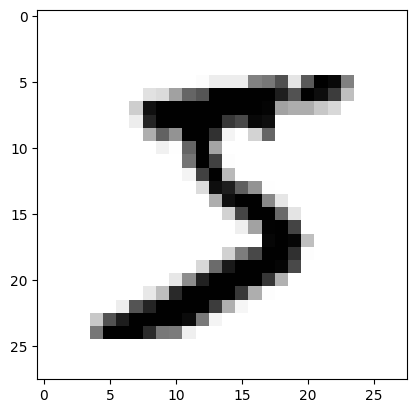

In [12]:
# now for taking a look on one of the digit from dataset we first grab an instance's feature vector and reshape it to 28x28 array and then 
# display it using imshow() function from matplotlib

import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28,28)
    plt.imshow(image, cmap="binary")

some_digit = X[0]  # we are choosing first element (index 0) from dataset and we already defined X = rex.data
plot_digit(some_digit) #calling the function by putting the some_digit value here in the custom function and then we use the show option to plot the image of that perticular array
plt.show()


In [13]:
y[0]
# this tell us the label of the above generated image that is 5 and the picture looks similar to 5

'5'

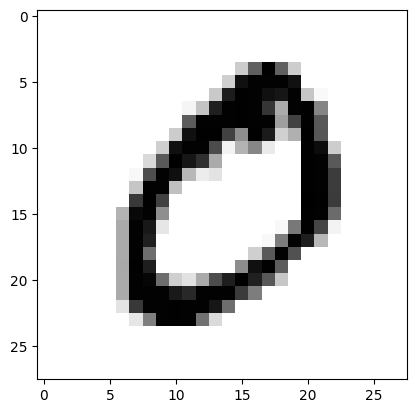

In [14]:
#playing with the above data for a bit :
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28,28)
    plt.imshow(image, cmap="binary")

value = X[1]
plot_digit(value)
plt.show()


#output looks like a potato lol but its a zero :) here for confirmation lets get the label 

In [15]:
y[1]
#hell yeah! we got our thing done here and our predictions were correct it was a zero 

'0'

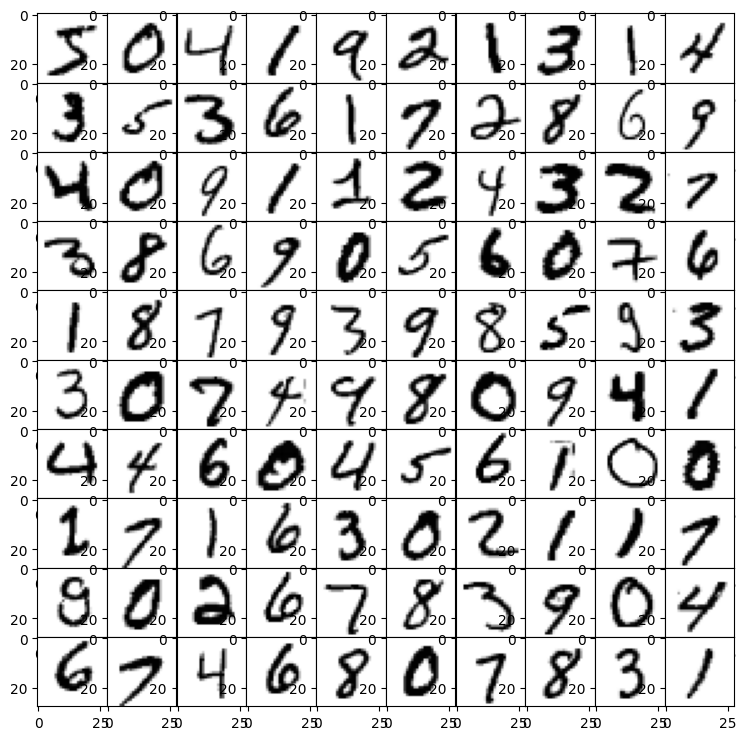

In [16]:
 #some more images from mnist dataset

plt.figure(figsize=(9, 9))
for idx, image_data in enumerate(X[:100]):
    plt.subplot(10, 10, idx + 1)
    plot_digit(image_data)
plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

In [17]:
#getting a test set before running into the real dataset 
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]
#that is the training set is first 60000 images and test set is last 10000  images

**Training a Binary Classifier**

In [18]:
#now we will be creating a one digit identifier that is for number 5 
#this will be an example of binary classifier capable of distinguishing between just two classes : either 5 or non 5 *kinda looks like a boolen alright*

In [19]:
#first of all we'll create targer vector for this classification task:
y_train_5 = (y_train == '5') # true for all 5s, false for all other digits
y_test_5 = (y_test == '5')

In [20]:
#using SDG classifier to train our classification model 
#SDG (stochastic gradient descent) classifier deals with training instances independently, one at a time , hence its also well suited for online learning
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [21]:
sgd_clf.predict([some_digit])

array([ True])

## Performance Measure

In [22]:
#evaluation of classifiers is more trickier then regressor!


*Measure Accuracy Using Cross-Validation*

In [23]:
#first creating a custom function to evaluate SDGClassifier using k fold validation where k= 3 for this case
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=10, scoring='accuracy')
#k fold will split the validation first into k folds (here 3 times) then train the model k times that is 3 times here holding a different fold each time for evaluaiton
#EDIT: experimenting with 10 for some better result *it takes time , the more the cv the more time it takes and it also depends on the size of your dataset*

array([0.96416667, 0.95866667, 0.96416667, 0.95833333, 0.96733333,
       0.96933333, 0.96433333, 0.96583333, 0.9575    , 0.96566667])

In [24]:
#dummy classifier that classifies every single image in the most frequent class (in this case negative class, i.e. non 5)
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
print(any(dummy_clf.predict(X_train))) #prints False: no 5s detected


False


In [25]:
#now finding the accuracy of the above model 
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy")
# as we can notice in the output the model has accuracy above 90 percent


array([0.90965, 0.90965, 0.90965])

In [26]:
#this demonstrates why accuracy is generally not a preferred performance measure for classifiers ecpecially for skewed datasets(i.e. when some classes are much more frequent than others).
#better way to do this is using CONFUSION MATRIX  (CM)

**Extras**

In [27]:
#we can implement cross validation ourself the results will be same as that of cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits = 3) #add shuffle = True if the dataset is not already suffled (in this case its suffeled)
for train_index, test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5[train_index]
    X_test_fold = X_train[test_index]
    y_test_fold = y_train_5[test_index]

    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred)) 


    #StratifiedKFold = KFold + guaranteed same class distribution in every fold = more fair and reliable accuracy scores, especially when your data is imbalanced.

0.95035
0.96035
0.9604


*Confusion Matrix*

In [28]:
#idea is to count the number of times instances of class A are classified as class B, for all A/B pairs
# set of predictions is needed so that they can be compared to actual targets (don't use the test set as it will be use at the very end of the project once we have a classifier that we are ready to launch)
# instead we use cross_val_predict() function it performs kfold cross validation and returns the predictions made on each test fold. we get a out of sample prediction for each instace in the training set

In [29]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train , y_train_5, cv = 3)

In [30]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train_5, y_train_pred)
cm

array([[53892,   687],
       [ 1891,  3530]])

In [31]:
#each code in the confusion matrix represents actual class and column = predicted class 
#first row of this matrix considers non 5 images (the negatives), 
# 53892 of them were classified correctly as non 5s (these are called true negatives/ type 1 error)
# 687 were wrongly classified non 5s these are false positives / Type 1 error
#Second row contains the positive class
# 1891 were wrongly classified as non5s (false negative/ Type 2 error)
# 3,530 were correctly classified as 5s(true positives)
# true classifier would have true positives and true negatives , so its confusion matrix should have nonzero values only on its main diagonal

In [32]:
y_train_perfect_predictions = y_train_5 # pretend we reached perfection
confusion_matrix(y_train_5, y_train_perfect_predictions)

array([[54579,     0],
       [    0,  5421]])

In [33]:
#precision of the classifier: accuracy of the positive predictions
#recall also known as true positive rate (TPR) this is the ratio of positive instaces that are correctly detected by the classifier

**Precision and Recall**

In [34]:
from sklearn.metrics import precision_score, recall_score
precision_score(y_train_5, y_train_pred) ## == 3530 / (687 + 3530)

0.8370879772350012

In [35]:
recall_score(y_train_5, y_train_pred) ## == 3530 / (1891 + 3530)

0.6511713705958311

In [36]:
from sklearn.metrics import f1_score
f1_score(y_train_5, y_train_pred)

0.7325171197343847

In [37]:
#f1 score is used to combine both precision and recall in a single metric 
# its the harmoninc mean of both precision and recall 
# f1_score() function is used to perform the task 
#increasing precision reduces recalls and vice versa this is called precision/recall tradeoff 

**Precision/Recall Trade-off**

In [38]:
# decision_function() method returns score for each instance 
y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([2164.22030239])

In [39]:
threshold = 0
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([ True])

In [40]:
#SDGClassifier uses a threshold equal to 0  so the preceding code returns the same result as the predict() method (i.e True) 
threshold = 3000
y_some_digit_pred= (y_scores > threshold)
y_some_digit_pred
#confirms that raising the threshold decreases recall 

array([False])

In [41]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method="decision_function")

from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

#using precision_recall_curve() function to compute precision and  recall for all possible thresholds  (the function adds a last precision of 1 and a last recall of 0, corresponding to an infinite threshold)


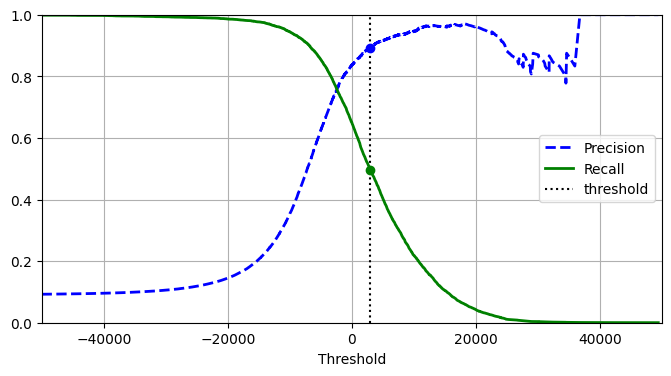

In [42]:
plt.figure(figsize=(8, 4))  # extra code – it's not needed, just formatting
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")

# extra code – this section just beautifies and saves Figure 3–5
idx = (thresholds >= threshold).argmax()  # first index ≥ threshold
plt.plot(thresholds[idx], precisions[idx], "bo")
plt.plot(thresholds[idx], recalls[idx], "go")
plt.axis([-50000, 50000, 0, 1])
plt.grid()
plt.xlabel("Threshold")
plt.legend(loc="center right")


plt.show()

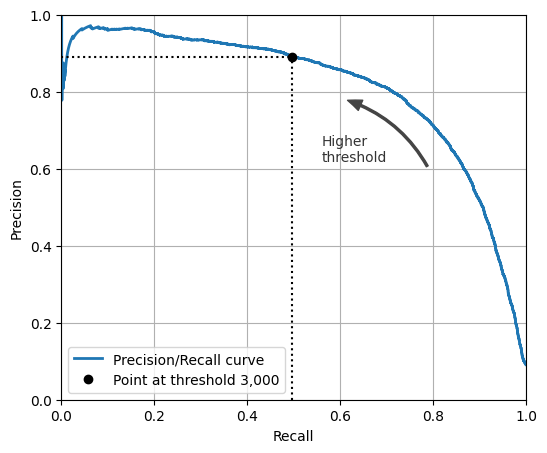

In [43]:

import matplotlib.patches as patches  # extra code – for the curved arrow

plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting

plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")

# extra code – just beautifies and saves Figure 3–6
plt.plot([recalls[idx], recalls[idx]], [0., precisions[idx]], "k:")
plt.plot([0.0, recalls[idx]], [precisions[idx], precisions[idx]], "k:")
plt.plot([recalls[idx]], [precisions[idx]], "ko",
         label="Point at threshold 3,000")
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.79, 0.60), (0.61, 0.78),
    connectionstyle="arc3,rad=.2",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.56, 0.62, "Higher\nthreshold", color="#333333")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend(loc="lower left")


plt.show()

In [44]:
#argmax()  method : returns the first  index of the maximum value, which in this case means the first True value:
idx_for_90_precision =  (precisions >= 0.90 ).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision

np.float64(3370.0194991439557)

In [45]:
#to make predictions  instead of  using predict()  method of classifiers  we can use:
y_train_pred_90 = (y_scores >= threshold_for_90_precision)

#checking the predictions precision and recall :
precision_score(y_train_5, y_train_pred_90)

0.9000345901072293

In [46]:
recall_at_90_precision = recall_score(y_train_5, y_train_pred_90)
recall_at_90_precision

0.4799852425751706

**The ROC  Curve**

In [47]:
#Receiver operating characteristic (ROC) curve is another common tool used with binary classifiers.
#ROC curve  plots the true positive rate(another name for recalling)against the false positive rate (FPR)
#FPR is the ratio of  negative instaces that are incorrectly classified as positive
#1-TNR(true negative ratio) : the ratio of negative instances  that're correctly  classified  as negative.
#TNR is also known as specificity.

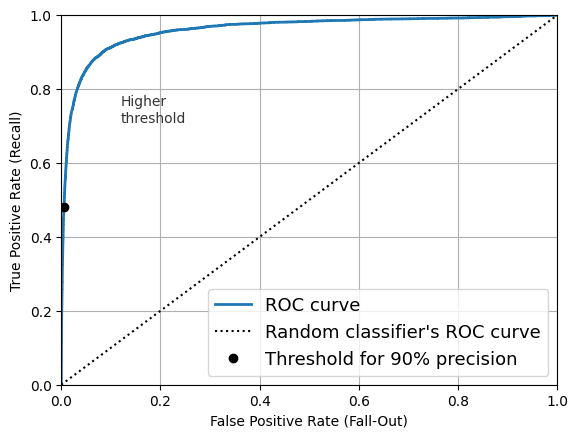

In [48]:
#using the roc_curve() function to compute the TPR and FPR for various threshold values:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0,1],[0,1], 'k:', label="Random classifier's ROC curve")
plt.plot([fpr_90],[tpr_90], "ko", label="Threshold for 90% precision")
plt.text(0.12, 0.71, "Higher\nthreshold", color="#333333")
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Recall)')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=13)
plt.show()

In [49]:
#one way to compare classifiers is to measure the area under curve(AUC) for a perfect classifier aoc = 1 and purely random classifier will have auc = 0.5
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5, y_scores)

0.9604938554008616

In [50]:
#creating RandomForestClassifier, whose PR curve and F1 score we can compare to those of the SDGClassifier:
from sklearn.ensemble import RandomForestClassifier
forest_clf = RandomForestClassifier(random_state=42)
#calling the cross_val_predict() function to train the RanodomForestClassifier 
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3, method="predict_proba")

In [51]:
y_probas_forest[:2]

array([[0.11, 0.89],
       [0.99, 0.01]])

In [52]:
#the above code predicts that the first image is positive with 89% probability 
# the second image is negative with 99% percent of probability

In [53]:
y_scores_forest = y_probas_forest[:, 1]
precision_forest, recall_forest, thresholds_forest = precision_recall_curve(y_train_5, y_scores_forest)

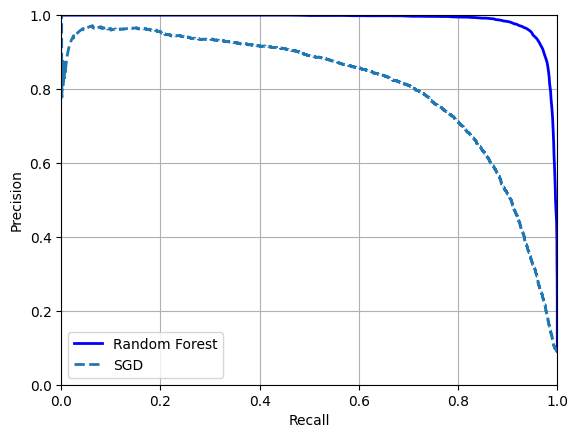

In [54]:
plt.plot(recall_forest, precision_forest, "b-", linewidth = 2, label="Random Forest")
plt.plot(recalls, precisions, "--", linewidth=2, label="SGD")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0,1,0,1])
plt.grid()
plt.legend(loc="lower left")
plt.show()

In [55]:
y_train_pred_forest = y_probas_forest[:,1] >= 0.5 #positive proba >= 50%
f1_score(y_train_5, y_train_pred_forest)

0.9274509803921569

In [56]:
roc_auc_score(y_train_5, y_scores_forest)

0.9983436731328145

## Multiclass Classification

In [57]:
from sklearn.svm import SVC

svm_clf = SVC(random_state=42)
svm_clf.fit(X_train[:2000], y_train[:2000]) # y_train, not y_train_5

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [58]:
svm_clf.predict([some_digit])

array(['5'], dtype=object)

In [59]:
#sdc = some digit score
sdc = svm_clf.decision_function([some_digit])
sdc.round(2)

array([[ 3.79,  0.73,  6.06,  8.3 , -0.29,  9.3 ,  1.75,  2.77,  7.21,
         4.82]])

In [60]:
class_id = sdc.argmax()
class_id

np.int64(5)

In [61]:
svm_clf.classes_

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype=object)

In [62]:
svm_clf.classes_[class_id]

'5'

In [63]:
#how to get all 45 OvO  scores if needed 
svm_clf.decision_function_shape= "ovo"
sdc_ovo = svm_clf.decision_function([some_digit])
sdc_ovo.round(2)

array([[ 0.11, -0.21, -0.97,  0.51, -1.01,  0.19,  0.09, -0.31, -0.04,
        -0.45, -1.28,  0.25, -1.01, -0.13, -0.32, -0.9 , -0.36, -0.93,
         0.79, -1.  ,  0.45,  0.24, -0.24,  0.25,  1.54, -0.77,  1.11,
         1.13,  1.04,  1.2 , -1.42, -0.53, -0.45, -0.99, -0.95,  1.21,
         1.  ,  1.  ,  1.08, -0.02, -0.67, -0.14, -0.3 , -0.13,  0.25]])

In [64]:
#if we want to force SK learn to use one-versus-one or one-versus-the-rest we use use OneVsRestClassifier or OneVsRestClassifier classes for this job
#Create an instance and pass a classifier to its constructor


from sklearn.multiclass import OneVsRestClassifier 

ovf = OneVsRestClassifier(SVC(random_state=42))
ovf.fit(X_train[:2000], y_train[:2000])

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",SVC(random_state=42)
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001


In [65]:
ovf.predict([some_digit])

array(['5'], dtype='<U1')

In [66]:
len(ovf.estimators_)

10

In [ ]:
#training SGDClassifier on a multiclass dataset and using it to make predictions :
sgf = SGDClassifier(random_state=42)
sgf.fit(X_train, y_train)
sgf.predict([some_digit])


In [ ]:
sgf.decision_function([some_digit]).round()

In [ ]:
from sklearn.preprocessing import StandardScaler

#$sgd_clf = SGDClassifier(max_iter=1000, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype("float64"))
cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3, scoring="accuracy")

## Error Analysis

In [ ]:
#assuming that we have a promising model and we want to find ways to improve it 
##one way to do it is to analyse the type of errors it makes

#First look at the confusion matrix  for this make predictions using cross_val_predict() fucntion then pass labels and predictions using confusion_matrix()function

#we use ConfusionMatrixDisplay.from_predictions() function to make the diagram of the predictions in the confusion matrix 


from sklearn.metrics import ConfusionMatrixDisplay

y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)
plt.rc('font', size=9)  # extra code – make the text smaller
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)
plt.show()


In [ ]:
plt.rc('font', size=10)  # extra code
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred,
                                        normalize="true", values_format=".0%")
plt.show()

In [ ]:
sample_weight = (y_train_pred != y_train)
plt.rc('font', size=10)  # extra code
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred,
                                        sample_weight=sample_weight,
                                        normalize="true", values_format=".0%")
plt.show()

In [ ]:
# extra code – this cell generates and saves Figure 3–9
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))
plt.rc('font', size=9)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axs[0])
axs[0].set_title("Confusion matrix")
plt.rc('font', size=10)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axs[1],
                                        normalize="true", values_format=".0%")
axs[1].set_title("CM normalized by row")

plt.show()

In [ ]:
cl_a, cl_b = '3', '5'
X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]
X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]
X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]
X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]

In [ ]:
# extra code – this cell generates and saves Figure 3–11
size = 5
pad = 0.2
plt.figure(figsize=(size, size))
for images, (label_col, label_row) in [(X_ba, (0, 0)), (X_bb, (1, 0)),
                                       (X_aa, (0, 1)), (X_ab, (1, 1))]:
    for idx, image_data in enumerate(images[:size*size]):
        x = idx % size + label_col * (size + pad)
        y = idx // size + label_row * (size + pad)
        plt.imshow(image_data.reshape(28, 28), cmap="binary",
                   extent=(x, x + 1, y, y + 1))
plt.xticks([size / 2, size + pad + size / 2], [str(cl_a), str(cl_b)])
plt.yticks([size / 2, size + pad + size / 2], [str(cl_b), str(cl_a)])
plt.plot([size + pad / 2, size + pad / 2], [0, 2 * size + pad], "k:")
plt.plot([0, 2 * size + pad], [size + pad / 2, size + pad / 2], "k:")
plt.axis([0, 2 * size + pad, 0, 2 * size + pad])
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.show()

## Multilabel Classification

In [ ]:
#classification system that outputs multiple binary tags is called a multilabel classification system

import numpy as np 
from sklearn.neighbors import KNeighborsClassifier
y_train_large = (y_train >= '7')
y_train_odd = (y_train.astype('int8') % 2 ==1 )
y_multilabel = np.c_[y_train_large, y_train_odd]

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)


In [ ]:
knn_clf.predict([some_digit])

In [ ]:
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)
f1_score(y_multilabel, y_train_knn_pred, average="macro")

In [ ]:
#the above approach assumes that all labels are equally important

In [ ]:
#Sklearn ClassifierChain by default uses the true lables for training, feeding each model the appropriate lables depending on their position in the chain
#setting the cv hyperparameter will use cross-validation to get "clean" (out of sample) predictions from each trained model for every instance in the training set 

from sklearn.multioutput import ClassifierChain

chain_clf = ClassifierChain(SVC(), cv=3, random_state=42)
chain_clf.fit(X_train[:2000], y_multilabel[:2000])
chain_clf.predict([some_digit])

## Multioutput Classification

In [ ]:

import numpy as np
#each lable can be multiclass (i.e. it can have more then two possible values)
np.random.seed(42) # to make this code example reproducible
noise = np.random.randint(0 , 100, (len(X_train), 784))
X_train_mod = X_train + noise
noise = np.random.randint(0, 100 , (len(X_test), 784))
X_test_mod = X_test + noise 
y_train_mod = X_train
y_test_mod = X_test

In [ ]:
plt.subplot(121); plot_digit(X_test_mod[0])
plt.subplot(122); plot_digit(y_test_mod[0])
save_fig("noisy_digit_example_plot")
plt.show()

In [ ]:
knn_clf =  KNeighborsClassifier()
knn_clf.fit(X_train_mod, y_train_mod)
clean_digit = knn_clf.predict([X_test_mod[0]])
plot_digit(clean_digit)
plt.show()

In [ ]:
#This journey ends here :) the next will be exercises  of this chapter 